# U-Net Training (10-Band + Indices)

Train a pixel-wise U-Net model on `new_dataset` (`*_img.tif` / `*_msk.tif`).

- Input: 16 features (`B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12,NDVI,NDBI,MNDWI,BSI,DBI,NSI`)
- Target classes: 1..4 (`0` is ignored in loss/metrics)
- Output artifact: `best_unet_10b.pth`

In [62]:
import sys
!{sys.executable} -m pip install -q torch torchvision rasterio scikit-learn matplotlib pandas


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: c:\Users\user\.pyenv\pyenv-win\versions\3.12.2\python.exe -m pip install --upgrade pip


In [ ]:
from pathlib import Path
import random
import os
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.backends.cudnn.benchmark = True
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

PROJECT_DIR = Path(r'c:/satellite/project')
DATASET_DIR = PROJECT_DIR / 'new_dataset'
OUT_MODEL = PROJECT_DIR / 'best_unet_10b.pth'

CLASS_NAMES = {1: 'Greenery', 2: 'Sand', 3: 'Water', 4: 'Cement'}
CLASS_IDS = [1, 2, 3, 4]
EPS = 1e-6

EPOCHS = 50
BATCH_SIZE = 16
LR = 1e-3
WEIGHT_DECAY = 1e-4

# Windows + rasterio in notebook multiprocessing can crash worker processes.
# Keep GPU training enabled, but use safer dataloader worker settings on Windows.
IS_WINDOWS = (os.name == 'nt')
NUM_WORKERS = 0 if IS_WINDOWS else (2 if torch.cuda.is_available() else 0)
PIN_MEMORY = torch.cuda.is_available()
print(f'DataLoader settings -> num_workers={NUM_WORKERS}, pin_memory={PIN_MEMORY}')
if IS_WINDOWS and NUM_WORKERS == 0:
    print('Using single-process DataLoader for stability on Windows.')

FEATURE_NAMES = ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12']

Device: cuda
GPU: NVIDIA GeForce RTX 4060
DataLoader settings -> num_workers=0, pin_memory=True
Using single-process DataLoader for stability on Windows.


In [64]:
img_paths = sorted(DATASET_DIR.glob('*_img.tif'))
msk_paths = sorted(DATASET_DIR.glob('*_msk.tif'))

def sample_id(p: Path) -> str:
    return p.name.replace('_img.tif', '').replace('_msk.tif', '')

img_lookup = {sample_id(p): p for p in img_paths}
msk_lookup = {sample_id(p): p for p in msk_paths}
paired_ids = sorted(set(img_lookup) & set(msk_lookup))
pairs = [(img_lookup[sid], msk_lookup[sid]) for sid in paired_ids]

train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, random_state=RANDOM_STATE)

print(f'Paired samples: {len(pairs)}')
print(f'Train pairs: {len(train_pairs)} | Val pairs: {len(val_pairs)}')
print(f'Unmatched images: {len(set(img_lookup)-set(msk_lookup))}')
print(f'Unmatched masks: {len(set(msk_lookup)-set(img_lookup))}')

Paired samples: 3126
Train pairs: 2500 | Val pairs: 626
Unmatched images: 0
Unmatched masks: 0


In [65]:
def normalize_spectral_10(cube: np.ndarray) -> np.ndarray:
    # new_dataset may contain extra channels; use first 10 as B2..B12 contract
    x = cube[:10].astype(np.float32)
    probe = np.nanpercentile(x, 99)
    if probe > 2.0:
        x = np.clip(x / 10000.0, 0.0, 1.0)
    else:
        x = np.clip(x, 0.0, 1.0)
    return x

def compute_spectral_indices(spectral_norm: np.ndarray) -> np.ndarray:
    # spectral_norm order: B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12
    b2 = spectral_norm[0]
    b3 = spectral_norm[1]
    b4 = spectral_norm[2]
    b8 = spectral_norm[6]
    b8a = spectral_norm[7]
    b11 = spectral_norm[8]

    ndvi = (b8 - b4) / (b8 + b4 + EPS)
    ndbi = (b11 - b8) / (b11 + b8 + EPS)
    mndwi = (b3 - b11) / (b3 + b11 + EPS)
    bsi = ((b11 + b4) - (b8 + b2)) / ((b11 + b4) + (b8 + b2) + EPS)
    dbi = ndbi - ndvi
    nsi = (b11 - b8a) / (b11 + b8a + EPS)

    return np.stack([ndvi, ndbi, mndwi, bsi, dbi, nsi], axis=0).astype(np.float32)

def build_unet_features(cube: np.ndarray) -> np.ndarray:
    spectral_norm = normalize_spectral_10(cube)  # (10, H, W)
    indices = compute_spectral_indices(spectral_norm)  # (6, H, W)
    return np.concatenate([spectral_norm], axis=0).astype(np.float32)  # (10, H, W)

class RasterSegDataset(Dataset):
    def __init__(self, pair_list, augment=False):
        self.pairs = pair_list
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, msk_path = self.pairs[idx]
        with rasterio.open(img_path) as src:
            image_cube = src.read().astype(np.float32)
        with rasterio.open(msk_path) as src:
            mask = src.read(1).astype(np.int64)

        x = build_unet_features(image_cube)
        y = mask

        if self.augment:
            if random.random() < 0.5:
                x = x[:, :, ::-1].copy()
                y = y[:, ::-1].copy()
            if random.random() < 0.5:
                x = x[:, ::-1, :].copy()
                y = y[::-1, :].copy()

        return torch.from_numpy(x), torch.from_numpy(y)

train_ds = RasterSegDataset(train_pairs, augment=True)
val_ds = RasterSegDataset(val_pairs, augment=False)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

x0, y0 = train_ds[0]
print('Sample tensor:', x0.shape, y0.shape, 'mask classes:', torch.unique(y0).tolist())

Sample tensor: torch.Size([10, 256, 256]) torch.Size([256, 256]) mask classes: [3]


In [66]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class UNetSmall(nn.Module):
    def __init__(self, in_ch=16, n_classes=5, base=32):
        super().__init__()
        self.enc1 = ConvBlock(in_ch, base)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(base, base*2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(base*2, base*4)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(base*4, base*8)

        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, 2)
        self.dec3 = ConvBlock(base*8, base*4)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, 2)
        self.dec2 = ConvBlock(base*4, base*2)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, 2)
        self.dec1 = ConvBlock(base*2, base)

        self.outc = nn.Conv2d(base, n_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        return self.outc(d1)

model = UNetSmall(in_ch=len(FEATURE_NAMES), n_classes=5, base=32).to(DEVICE)
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

sum(p.numel() for p in model.parameters())

1930565

In [67]:
def iou_per_class_np(y_true, y_pred, class_ids):
    out = {}
    for c in class_ids:
        inter = np.sum((y_true == c) & (y_pred == c))
        union = np.sum((y_true == c) | (y_pred == c))
        out[c] = inter / union if union > 0 else np.nan
    return out

def run_epoch(loader, training=True):
    model.train(training)
    losses = []
    all_true = []
    all_pred = []

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            logits = model(xb)
            loss = criterion(logits, yb)
            if training:
                loss.backward()
                optimizer.step()

        losses.append(loss.item())

        pred = torch.argmax(logits, dim=1)
        y_true_np = yb.detach().cpu().numpy()
        y_pred_np = pred.detach().cpu().numpy()

        valid = y_true_np != 0
        if np.any(valid):
            all_true.append(y_true_np[valid])
            all_pred.append(y_pred_np[valid])

    if len(all_true) == 0:
        return float(np.mean(losses)), np.nan, np.nan, {c: np.nan for c in CLASS_IDS}

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    ious = iou_per_class_np(y_true, y_pred, CLASS_IDS)
    miou = float(np.nanmean([ious[c] for c in CLASS_IDS]))
    acc = float(np.mean(y_true == y_pred))
    return float(np.mean(losses)), acc, miou, ious

In [68]:
history = []
best_miou = -1.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_miou, tr_ious = run_epoch(train_loader, training=True)
    va_loss, va_acc, va_miou, va_ious = run_epoch(val_loader, training=False)

    scheduler.step(va_miou if np.isfinite(va_miou) else 0.0)

    row = {
        'epoch': epoch,
        'train_loss': tr_loss,
        'train_acc': tr_acc,
        'train_miou': tr_miou,
        'val_loss': va_loss,
        'val_acc': va_acc,
        'val_miou': va_miou,
        'acc_gap_train_minus_val': (tr_acc - va_acc) if (np.isfinite(tr_acc) and np.isfinite(va_acc)) else np.nan,
        'lr': optimizer.param_groups[0]['lr'],
    }
    for c in CLASS_IDS:
        row[f'val_iou_{CLASS_NAMES[c]}'] = va_ious[c]
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} tr_mIoU={tr_miou:.4f} | "
        f"va_loss={va_loss:.4f} va_acc={va_acc:.4f} va_mIoU={va_miou:.4f} | "
        f"acc_gap={row['acc_gap_train_minus_val']:.4f}"
    )

    if np.isfinite(va_miou) and va_miou > best_miou:
        best_miou = va_miou
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

hist_df = pd.DataFrame(history)
hist_df.tail()

Epoch 01/10 | tr_loss=0.4848 tr_acc=0.8750 tr_mIoU=0.7713 | va_loss=0.2705 va_acc=0.9254 va_mIoU=0.8578 | acc_gap=-0.0504
Epoch 02/10 | tr_loss=0.2996 tr_acc=0.9068 tr_mIoU=0.8245 | va_loss=0.2361 va_acc=0.9140 va_mIoU=0.8482 | acc_gap=-0.0072
Epoch 03/10 | tr_loss=0.2633 tr_acc=0.9149 tr_mIoU=0.8395 | va_loss=0.1800 va_acc=0.9365 va_mIoU=0.8769 | acc_gap=-0.0216
Epoch 04/10 | tr_loss=0.2465 tr_acc=0.9186 tr_mIoU=0.8448 | va_loss=0.1691 va_acc=0.9384 va_mIoU=0.8798 | acc_gap=-0.0199
Epoch 05/10 | tr_loss=0.2322 tr_acc=0.9255 tr_mIoU=0.8568 | va_loss=0.1417 va_acc=0.9496 va_mIoU=0.9004 | acc_gap=-0.0241
Epoch 06/10 | tr_loss=0.2021 tr_acc=0.9349 tr_mIoU=0.8737 | va_loss=0.1905 va_acc=0.9325 va_mIoU=0.8724 | acc_gap=0.0025
Epoch 07/10 | tr_loss=0.1704 tr_acc=0.9457 tr_mIoU=0.8929 | va_loss=0.1328 va_acc=0.9546 va_mIoU=0.9111 | acc_gap=-0.0088
Epoch 08/10 | tr_loss=0.1946 tr_acc=0.9377 tr_mIoU=0.8794 | va_loss=0.2266 va_acc=0.8973 va_mIoU=0.8120 | acc_gap=0.0404
Epoch 09/10 | tr_loss=0.18

,epoch,train_loss,train_acc,train_miou,val_loss,val_acc,val_miou,acc_gap_train_minus_val,lr,val_iou_Greenery,val_iou_Sand,val_iou_Water,val_iou_Cement
5,6,0.202056,0.934920,0.873743,0.190501,0.932468,0.872407,0.002452,0.001,0.845827,0.901622,0.990715,0.751465
6,7,0.170424,0.945732,0.892946,0.132752,0.954573,0.911125,-0.008841,0.001,0.898038,0.925698,0.992386,0.828379
7,8,0.194587,0.937688,0.879420,0.226594,0.897293,0.811958,0.040395,0.001,0.879628,0.813273,0.985963,0.568969
8,9,0.181179,0.941643,0.885761,0.187161,0.940432,0.881539,0.001212,0.001,0.821331,0.936303,0.988794,0.779728
9,10,0.157140,0.950859,0.901694,0.160741,0.948471,0.897685,0.002388,0.001,0.873571,0.937967,0.986792,0.792411


In [69]:
if best_state is not None:
    model.load_state_dict(best_state)

payload = {
    'model_state_dict': model.state_dict(),
    'model_type': 'unet_small',
    'in_channels': len(FEATURE_NAMES),
    'num_classes': 5,
    'feature_names': FEATURE_NAMES,
    'class_names': CLASS_NAMES,
    'best_val_miou': float(best_miou),
    'config': {
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'lr': LR,
        'weight_decay': WEIGHT_DECAY,
        'random_state': RANDOM_STATE
    }
}

torch.save(payload, OUT_MODEL)
print('Saved:', OUT_MODEL)
print('Best val mIoU:', round(float(best_miou), 4))

Saved: c:\satellite\project\best_unet_10b.pth
Best val mIoU: 0.9111


              precision    recall  f1-score   support

    Greenery       0.96      0.94      0.95   8732455
        Sand       0.97      0.95      0.96  14544276
       Water       1.00      0.99      1.00   9367523
      Cement       0.88      0.94      0.91   8303751

    accuracy                           0.95  40948005
   macro avg       0.95      0.95      0.95  40948005
weighted avg       0.96      0.95      0.95  40948005



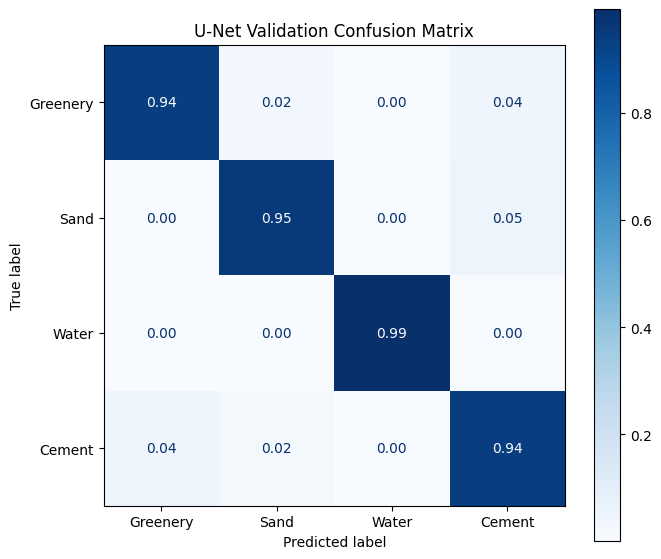

In [70]:
# Final validation report (excluding class 0)
model.eval()
all_true, all_pred = [], []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        pred = torch.argmax(logits, dim=1).cpu().numpy()
        y_true = yb.numpy()
        valid = y_true != 0
        if np.any(valid):
            all_true.append(y_true[valid])
            all_pred.append(pred[valid])

all_true = np.concatenate(all_true)
all_pred = np.concatenate(all_pred)

print(classification_report(
    all_true,
    all_pred,
    labels=CLASS_IDS,
    target_names=[CLASS_NAMES[c] for c in CLASS_IDS],
    zero_division=0
))

cm = confusion_matrix(all_true, all_pred, labels=CLASS_IDS, normalize='true')
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=[CLASS_NAMES[c] for c in CLASS_IDS]).plot(ax=ax, cmap='Blues', values_format='.2f')
ax.set_title('U-Net Validation Confusion Matrix')
plt.tight_layout()
plt.show()